In [29]:
# CELL 1 — Imports & Setup
import sys, os
import pandas as pd
import plotly.express as px
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PLOTLY_TEMPLATE = 'plotly_dark'
DATA_PATH       = 'C:\\Users\\Rishj\\OneDrive\\Desktop\\patient_satisfaction\\data\\raw\\sample_data.csv'
PROCESSED_DIR   = 'C:\\Users\\Rishj\\OneDrive\\Desktop\\patient_satisfaction\\data\\processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)
print('✅ Cell 1 complete — imports loaded')

✅ Cell 1 complete — imports loaded


In [30]:
# ── CELL 2 — Load Raw CSV (Robust Version) ───────────────────────

import os

DATA_PATH = r"C:\Users\Rishj\OneDrive\Desktop\patient_satisfaction\data\raw\sample_data.csv"

# 🔍 Step 1: Check if file exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"❌ File not found at path:\n{DATA_PATH}")

print("📂 Loading dataset...")

# 📥 Step 2: Load CSV safely (handles bad rows)
try:
    df_raw = pd.read_csv(
        DATA_PATH,
        engine='python',        # more flexible parser
        on_bad_lines='warn'     # warns instead of crashing
    )
    print("✅ Data loaded successfully!")

except Exception as e:
    print("❌ Error while loading data:")
    print(e)
    raise

# 📊 Step 3: Basic info
print(f"\n📊 Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\n📌 Columns: {list(df_raw.columns)}")

# 👀 Step 4: Preview data
display(df_raw.head())

📂 Loading dataset...
✅ Data loaded successfully!

📊 Shape: 59 rows × 8 columns

📌 Columns: ['patient_id', 'date', 'department', 'overall_rating', 'wait_time_rating', 'staff_rating', 'cleanliness_rating', 'feedback_text']


,patient_id,date,department,overall_rating,wait_time_rating,staff_rating,cleanliness_rating,feedback_text
0,P001,2024-01-03,Cardiology,5,4,5,5,The doctors and nurses were absolutely wonderf...
1,P002,2024-01-05,Emergency,2,1,3,2,I waited over four hours in the emergency room...
2,P003,2024-01-07,Orthopedics,4,3,4,4,The surgical team was professional and the rec...
3,P004,2024-01-09,Pediatrics,5,5,5,5,My child was treated with such kindness. The p...
4,P005,2024-01-11,Radiology,3,2,4,3,The MRI scan itself was fine but waiting over ...


In [31]:
# CELL 2B — Data Validation  ★ NEW
# Validates the raw DataFrame before running the pipeline.
# Informational only — does NOT stop notebook execution.
from modules.data_validator import validate_dataframe

print('=' * 60)
print('DATA VALIDATION REPORT')
print('=' * 60)

issues = validate_dataframe(df_raw)

if not issues:
    print('✅ All 7 validation checks passed.')
    print(f'   Rows       : {len(df_raw)}')
    print(f'   Columns    : {list(df_raw.columns)}')
    depts = df_raw['department'].nunique() if 'department' in df_raw.columns else 'N/A'
    print(f'   Departments: {depts}')
else:
    print(f'⚠️  {len(issues)} validation issue(s) found:\n')
    for i, issue in enumerate(issues, 1):
        print(f'  {i}. {issue}')
    print('\n→ Pipeline will still run.')
    print('  Fix the warnings above for best results.')

print('=' * 60)
print('✅ Cell 2B complete — validation done')

2026-04-18 07:36:41 | INFO     | modules.data_validator | Validation passed. Shape: (59, 8)


DATA VALIDATION REPORT
✅ All 7 validation checks passed.
   Rows       : 59
   Columns    : ['patient_id', 'date', 'department', 'overall_rating', 'wait_time_rating', 'staff_rating', 'cleanliness_rating', 'feedback_text']
   Departments: 8
✅ Cell 2B complete — validation done


In [32]:
from modules.data_cleaner      import clean_data
from modules.preprocessor      import preprocess_data
from modules.feature_engineer  import engineer_features
from modules.sentiment         import run_sentiment_analysis
from modules.issue_categorizer import categorize_issues
from modules.priority_scorer   import score_priorities
from modules.action_mapper     import map_actions
from modules.insight_generator import generate_insights
from utils.helpers             import find_rating_col, find_text_col

pipeline_steps = [
    ('🧹 Cleaning data',             clean_data),
    ('⚙️  Preprocessing text',         preprocess_data),
    ('🔧 Engineering features',       engineer_features),
    ('💬 Running sentiment analysis', run_sentiment_analysis),
    ('🏷️  Categorizing issues',        categorize_issues),
    ('⚡ Scoring priorities',          score_priorities),
    ('🗺️  Mapping actions',            map_actions),
]

df = df_raw.copy()
for label, func in pipeline_steps:
    print(f'{label}...')
    df = func(df.copy())

print(f'\n✅ Pipeline complete.')
print(f'   Processed shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   New columns: {[c for c in df.columns if c not in df_raw.columns]}')

out_csv = os.path.join(PROCESSED_DIR, 'processed_data.csv')
df.to_csv(out_csv, index=False)
print(f'\n✅ Saved → {out_csv}')

2026-04-18 07:36:44.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 07:36:44.800 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 07:36:44.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-18 07:36:44 | INFO     | modules.data_cleaner | Cleaning complete: 0 rows removed, 59 remaining
2026-04-18 07:36:44 | INFO     | modules.preprocessor | Text preprocessing applied to column: feedback_text
2026-04-18 07:36:44 | INFO     | modules.feature_engineer | Feature engineering complete. New features added.
2026-04-18 07:36:44 | INFO     | modules.sentiment | Sentiment analysis complete. Distribution: {'Positive': 42, 'Negative': 15, 'Neutral': 2}
2026-04-18 07:36:44 | INFO     | modules.issue_categorizer | Issue categorisation complete. Top category: Treatment Quality
2026-04-18 07:36:44 | INFO     | 

🧹 Cleaning data...
⚙️  Preprocessing text...
🔧 Engineering features...
💬 Running sentiment analysis...
🏷️  Categorizing issues...
⚡ Scoring priorities...
🗺️  Mapping actions...

✅ Pipeline complete.
   Processed shape : 59 rows × 31 columns
   New columns: ['clean_text', 'department_Cardiology', 'department_Emergency', 'department_Gynecology', 'department_Neurology', 'department_Oncology', 'department_Orthopedics', 'department_Pediatrics', 'department_Radiology', 'word_count', 'char_count', 'has_feedback', 'rating_band', 'is_promoter', 'is_detractor', 'nps_category', 'composite_score', 'vader_compound', 'sentiment_label', 'sentiment_score', 'issue_category', 'priority_score', 'priority_label', 'recommended_action']

✅ Saved → C:\Users\Rishj\OneDrive\Desktop\patient_satisfaction\data\processed\processed_data.csv


In [33]:
# CELL 4 — Dataset Overview & Statistics
rating_col = find_rating_col(df)
text_col   = find_text_col(df)

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total responses    : {len(df)}')
if 'department' in df.columns:
    print(f'Departments        : {df["department"].nunique()} — {list(df["department"].unique())}')
if 'date' in df.columns:
    d = pd.to_datetime(df['date'], errors='coerce')
    print(f'Date range         : {d.min().date()} → {d.max().date()}')
if rating_col:
    print(f'Avg overall rating : {df[rating_col].mean():.2f} / 5')
    print(f'Median rating      : {df[rating_col].median():.1f}')
if 'sentiment_label' in df.columns:
    vc = df['sentiment_label'].value_counts(normalize=True)*100
    print(f'Positive sentiment : {vc.get("Positive",0):.1f}%')
    print(f'Negative sentiment : {vc.get("Negative",0):.1f}%')
if 'priority_score' in df.columns:
    print(f'Critical cases (≥7): {(df["priority_score"]>=7).sum()}')
print('=' * 60)
df.describe()

DATASET OVERVIEW
Total responses    : 59
Date range         : 2024-01-03 → 2024-05-03
Avg overall rating : 3.56 / 5
Median rating      : 4.0
Positive sentiment : 71.2%
Negative sentiment : 25.4%
Critical cases (≥7): 8


,overall_rating,wait_time_rating,staff_rating,cleanliness_rating,department_Cardiology,department_Emergency,department_Gynecology,department_Neurology,department_Oncology,department_Orthopedics,department_Pediatrics,department_Radiology,word_count,char_count,has_feedback,is_promoter,is_detractor,composite_score,vader_compound,sentiment_score,priority_score
count,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00,59.00
mean,3.56,3.17,3.86,3.69,0.15,0.15,0.10,0.12,0.12,0.12,0.12,0.12,13.71,109.25,1.00,0.58,0.25,3.58,0.34,3.34,3.46
std,1.29,1.32,1.17,1.19,0.36,0.36,0.30,0.33,0.33,0.33,0.33,0.33,1.27,9.02,0.00,0.50,0.44,1.14,0.59,1.48,2.68
min,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00,88.00,1.00,0.00,0.00,1.00,-0.92,0.20,0.00
25%,2.50,2.00,3.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13.00,103.00,1.00,0.00,0.00,2.50,-0.08,2.29,1.59
50%,4.00,3.00,4.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,109.00,1.00,1.00,0.00,4.00,0.65,4.12,2.14
75%,5.00,4.00,5.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,14.50,117.00,1.00,1.00,0.50,4.67,0.81,4.54,5.79
max,5.00,5.00,5.00,5.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,17.00,125.00,1.00,1.00,1.00,5.00,0.91,4.77,10.00


In [34]:
# ── CELL 5 — Rating Distribution & Department Comparison (Robust) ───────────

# ✅ Step 0: Normalize column names (VERY IMPORTANT)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# ✅ Step 1: Auto-detect rating column
rating_col = find_rating_col(df)

# ✅ Step 2: Auto-detect department column
dept_col = None
for col in df.columns:
    if 'department' in col:
        dept_col = col
        break

# 🧠 Debug (optional)
print(f"Detected rating column: {rating_col}")
print(f"Detected department column: {dept_col}")

# ✅ Step 3: Plot only if rating exists
if rating_col:

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=['Overall Rating Distribution', 'Avg Rating by Department']
    )

    # 📊 Rating Distribution
    hist_data = df[rating_col].value_counts().sort_index()

    fig.add_trace(
        go.Bar(
            x=hist_data.index,
            y=hist_data.values,
            marker_color=['#ef4444', '#f97316', '#eab308', '#22c55e', '#16a34a'],
            name='Count',
            showlegend=False
        ),
        row=1, col=1
    )

    # 📊 Department-wise Avg Rating (only if found)
    if dept_col:
        dept_avg = df.groupby(dept_col)[rating_col].mean().sort_values()

        fig.add_trace(
            go.Bar(
                x=dept_avg.values,
                y=dept_avg.index,
                orientation='h',
                marker_color=['#6366f1'] * len(dept_avg),
                name='Avg Rating',
                showlegend=False,
                text=[f'{v:.2f}' for v in dept_avg.values],
                textposition='outside'
            ),
            row=1, col=2
        )
    else:
        print("⚠️ No department column detected — skipping department comparison")

    fig.update_layout(
        template=PLOTLY_TEMPLATE,
        height=400,
        title_text='Rating Analysis'
    )

    fig.show()

# ── 📈 Rating Trend Over Time ─────────────────────────────────────

# Auto-detect date column
date_col = None
for col in df.columns:
    if 'date' in col:
        date_col = col
        break

if rating_col and date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    trend = (
        df.groupby(df[date_col].dt.to_period('M'))[rating_col]
        .mean()
        .reset_index()
    )

    trend[date_col] = trend[date_col].astype(str)

    fig2 = px.line(
        trend,
        x=date_col,
        y=rating_col,
        title='Rating Trend Over Time',
        markers=True,
        template=PLOTLY_TEMPLATE,
        color_discrete_sequence=['#8b5cf6']
    )

    fig2.show()
else:
    print("⚠️ Date column not found — skipping trend analysis")

# ── 🥧 NPS Category Breakdown ─────────────────────────────────────

# Auto-detect NPS column
nps_col = None
for col in df.columns:
    if 'nps' in col:
        nps_col = col
        break

if nps_col:
    nps_counts = df[nps_col].value_counts().reset_index()
    nps_counts.columns = [nps_col, 'count']

    fig3 = px.pie(
        nps_counts,
        names=nps_col,
        values='count',
        hole=0.4,
        title='NPS Category Breakdown',
        template=PLOTLY_TEMPLATE,
        color=nps_col,
        color_discrete_map={
            'Promoter': '#22c55e',
            'Passive': '#f59e0b',
            'Detractor': '#ef4444'
        }
    )

    fig3.show()
else:
    print("⚠️ NPS column not found — skipping NPS chart")

print("✅ Cell 5 complete (Robust Version)")

Detected rating column: overall_rating
Detected department column: department_cardiology


✅ Cell 5 complete (Robust Version)


In [35]:
# CELL 6 — Sentiment Analysis Visualisation (FIXED)

if 'sentiment_label' in df.columns:

    # 🎨 Colors
    colors = {
        'Positive': '#22c55e',
        'Neutral': '#f59e0b',
        'Negative': '#ef4444'
    }

    # ── 🧠 FIX 1: Handle one-hot department columns ─────────────
    dept_cols = [col for col in df.columns if col.startswith('department_')]

    if dept_cols:
        # Convert one-hot → single department column
        df['department'] = df[dept_cols].idxmax(axis=1)
        df['department'] = df['department'].str.replace('department_', '')

    # ── 📊 Create subplot ───────────────────────────────────────
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'pie'}, {'type': 'bar'}]],
        subplot_titles=['Sentiment Distribution', 'Sentiment by Department']
    )

    # ── 🥧 Sentiment Distribution ───────────────────────────────
    sc = df['sentiment_label'].value_counts()

    fig.add_trace(
        go.Pie(
            labels=sc.index,
            values=sc.values,
            marker_colors=[colors.get(l, '#94a3b8') for l in sc.index],
            hole=0.4
        ),
        row=1, col=1
    )

    # ── 📊 Sentiment by Department (FIXED) ─────────────────────
    if 'department' in df.columns:

        ds = (
            df.groupby(['department', 'sentiment_label'])
            .size()
            .unstack(fill_value=0)
        )

        for s in ['Positive', 'Neutral', 'Negative']:
            if s in ds.columns:
                fig.add_trace(
                    go.Bar(
                        name=s,
                        x=ds.index,
                        y=ds[s],
                        marker_color=colors[s]
                    ),
                    row=1, col=2
                )
    else:
        print("⚠️ No department column found")

    # ── Layout ────────────────────────────────────────────────
    fig.update_layout(
        template=PLOTLY_TEMPLATE,
        height=420,
        barmode='group',   # 🔥 FIX: better than stack
        title_text='Sentiment Analysis'
    )

    fig.show()

    # ── 📈 VADER Distribution ─────────────────────────────────
    if 'vader_compound' in df.columns:
        fig2 = px.histogram(
            df,
            x='vader_compound',
            nbins=30,
            title='VADER Compound Score Distribution',
            template=PLOTLY_TEMPLATE,
            color_discrete_sequence=['#6366f1']
        )

        fig2.add_vline(
            x=0.05,
            line_dash='dash',
            line_color='#22c55e',
            annotation_text='Positive (+0.05)'
        )

        fig2.add_vline(
            x=-0.05,
            line_dash='dash',
            line_color='#ef4444',
            annotation_text='Negative (−0.05)'
        )

        fig2.show()

print('✅ Cell 6 complete')

✅ Cell 6 complete


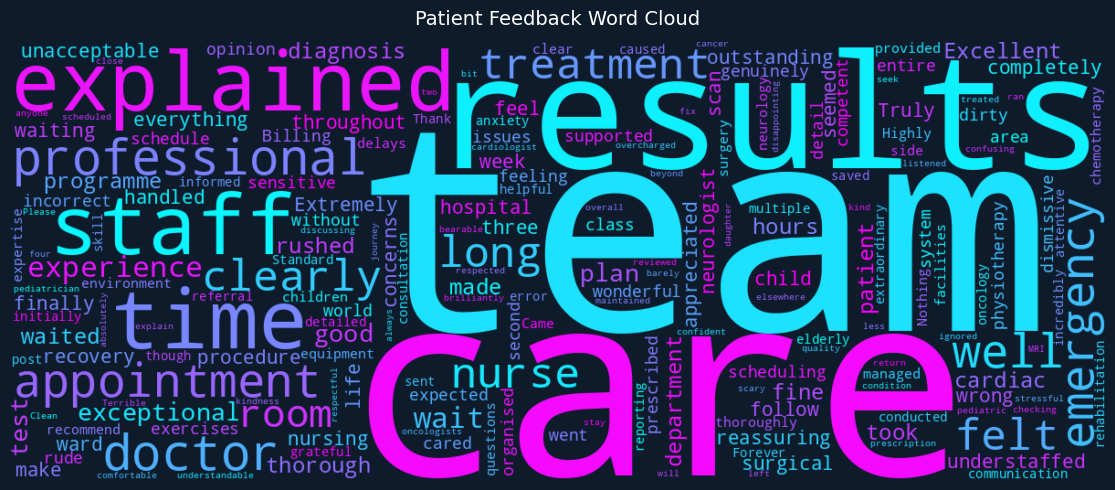

✅ Cell 7 complete (Upgraded)


In [ ]:
# CELL 7 — Word Cloud & Issue Categorisation (UPGRADED)
text_col = find_text_col(df)

if text_col and text_col in df.columns:

    # ── 🧠 TEXT PREPARATION ─────────────────────────────────────
    all_text = ' '.join(df[text_col].dropna().astype(str).tolist())

    # ── ☁️ WORD CLOUD ──────────────────────────────────────────
    if all_text.strip():
        wc = WordCloud(
            width=1200,
            height=480,
            background_color='#0d1b2a',
            colormap='cool',
            max_words=200
        ).generate(all_text)

        fig_wc, ax = plt.subplots(figsize=(14, 5))
        fig_wc.patch.set_facecolor('#0d1b2a')
        ax.set_facecolor('#0d1b2a')

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title('Patient Feedback Word Cloud', color='white', fontsize=14, pad=12)

        plt.tight_layout()
        plt.show()

    # ── 🔍 AUTO ISSUE CATEGORIZATION ───────────────────────────
    def categorize_issue(text):
        text = text.lower()

        if any(word in text for word in ['wait', 'delay', 'late', 'hours']):
            return 'Waiting Time'
        elif any(word in text for word in ['rude', 'staff', 'behavior', 'attitude']):
            return 'Staff Behaviour'
        elif any(word in text for word in ['clean', 'hygiene', 'dirty']):
            return 'Cleanliness'
        elif any(word in text for word in ['bill', 'charge', 'cost', 'expensive']):
            return 'Billing Issue'
        elif any(word in text for word in ['doctor', 'treatment', 'diagnosis']):
            return 'Medical Care'
        else:
            return 'General'

    # Create column
    df['issue_category'] = df[text_col].astype(str).apply(categorize_issue)

    # ── 📊 ISSUE DISTRIBUTION ─────────────────────────────────
    cat_c = df['issue_category'].value_counts().reset_index()
    cat_c.columns = ['category', 'count']

    fig = px.bar(
        cat_c,
        x='category',
        y='count',
        color='count',
        color_continuous_scale='Viridis',
        title='Issue Category Distribution',
        template=PLOTLY_TEMPLATE
    )

    fig.update_layout(xaxis_tickangle=-30)
    fig.show()

    # ── 🧩 DEPARTMENT HEATMAP (FIXED for one-hot) ─────────────

    # Detect one-hot department columns
    dept_cols = [col for col in df.columns if col.startswith('department_')]

    if dept_cols:
        df['department'] = df[dept_cols].idxmax(axis=1)
        df['department'] = df['department'].str.replace('department_', '')

    if 'department' in df.columns:

        heat = (
            df.groupby(['department', 'issue_category'])
            .size()
            .unstack(fill_value=0)
        )

        fig2 = px.imshow(
            heat,
            title='Issues by Department (Heatmap)',
            color_continuous_scale='Purples',
            aspect='auto',
            text_auto=True,
            template=PLOTLY_TEMPLATE
        )

        fig2.show()

    else:
        print("⚠️ No department data available for heatmap")

else:
    print("⚠️ No valid text column found")

print("✅ Cell 7 complete (Upgraded)")

In [41]:
# CELL 8 — Advanced Feedback Summarizer

from collections import Counter
import re

text_col = find_text_col(df)

if text_col and text_col in df.columns:

    # ── 🧹 Clean Text ─────────────────────────────────────────
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        return text

    df['clean_text'] = df[text_col].fillna("").apply(clean_text)

    # ── 🧠 Keyword Extraction ─────────────────────────────────
    all_words = ' '.join(df['clean_text']).split()

    stopwords = set([
        'the','is','and','to','of','in','for','on','with','was','were',
        'it','this','that','very','had','have','has','a','an','at','by',
        'from','as','but','not','they','their','them','i','we','you'
    ])

    filtered_words = [w for w in all_words if w not in stopwords and len(w) > 3]

    word_freq = Counter(filtered_words).most_common(15)

    # ── 📊 Show Top Keywords ──────────────────────────────────
    print("🔑 Top Keywords:")
    for word, freq in word_freq:
        print(f"{word}: {freq}")

    # ── 📈 Sentiment Summary ─────────────────────────────────
    summary_lines = []

    if 'sentiment_label' in df.columns:
        total = len(df)
        pos = (df['sentiment_label'] == 'Positive').sum()
        neg = (df['sentiment_label'] == 'Negative').sum()
        neu = (df['sentiment_label'] == 'Neutral').sum()

        summary_lines.append(f"📊 Total Responses: {total}")
        summary_lines.append(f"📈 Positive: {pos/total*100:.1f}%")
        summary_lines.append(f"📉 Negative: {neg/total*100:.1f}%")
        summary_lines.append(f"⚖️ Neutral: {neu/total*100:.1f}%")

    # ── 🧠 Theme Detection ───────────────────────────────────
    top_words = [w for w, _ in word_freq[:5]]
    summary_lines.append(f"\n🧠 Key Themes: {', '.join(top_words)}")

    # ── ⚠️ Issue Detection ───────────────────────────────────
    issue_map = {
        'Waiting Time': ['wait','delay','hours','late'],
        'Staff Behaviour': ['rude','staff','attitude','behavior'],
        'Cleanliness': ['clean','dirty','hygiene'],
        'Billing': ['bill','charge','cost','expensive'],
        'Medical Care': ['doctor','treatment','diagnosis']
    }

    detected_issues = []

    for issue, keywords in issue_map.items():
        if any(word in filtered_words for word in keywords):
            detected_issues.append(issue)

    if detected_issues:
        summary_lines.append(f"\n⚠️ Major Issues: {', '.join(detected_issues)}")

    # ── 🏥 Department-wise Insights ──────────────────────────
    dept_cols = [col for col in df.columns if col.startswith('department_')]

    if dept_cols:
        df['department'] = df[dept_cols].idxmax(axis=1)
        df['department'] = df['department'].str.replace('department_', '')

    if 'department' in df.columns and 'sentiment_label' in df.columns:

        dept_sent = (
            df.groupby('department')['sentiment_label']
            .apply(lambda x: (x == 'Positive').mean() * 100)
            .sort_values(ascending=False)
        )

        best_dept = dept_sent.idxmax()
        worst_dept = dept_sent.idxmin()

        summary_lines.append(f"\n🏆 Best Department: {best_dept} ({dept_sent.max():.1f}% positive)")
        summary_lines.append(f"⚠️ Needs Improvement: {worst_dept} ({dept_sent.min():.1f}% positive)")

    # ── 📝 Final Summary Output ──────────────────────────────
    print("\n" + "="*50)
    print("📝 FEEDBACK SUMMARY REPORT")
    print("="*50)

    for line in summary_lines:
        print(line)

    print("\n" + "="*50)

else:
    print("⚠️ No valid text column found")

🔑 Top Keywords:
team: 17
care: 14
results: 10
explained: 9
staff: 9
professional: 8
emergency: 7
appointment: 7
felt: 6
clearly: 6
long: 6
doctor: 6
treatment: 6
been: 6
which: 6

📝 FEEDBACK SUMMARY REPORT
📊 Total Responses: 59
📈 Positive: 71.2%
📉 Negative: 25.4%
⚖️ Neutral: 3.4%

🧠 Key Themes: team, care, results, explained, staff

⚠️ Major Issues: Waiting Time, Staff Behaviour, Cleanliness, Medical Care

🏆 Best Department: oncology (85.7% positive)
⚠️ Needs Improvement: emergency (55.6% positive)



In [38]:
# CELL 8 — Priority Scoring & Correlation Heatmap
if 'priority_score' in df.columns:
    labels_p  = ['🟢 Low (<3)','🟡 Medium (3–5)','🟠 High (5–7)','🔴 Critical (≥7)']
    counts_p  = [(df['priority_score']<3).sum(),
                 ((df['priority_score']>=3)&(df['priority_score']<5)).sum(),
                 ((df['priority_score']>=5)&(df['priority_score']<7)).sum(),
                 (df['priority_score']>=7).sum()]
    colors_p  = ['#22c55e','#eab308','#f97316','#ef4444']
    fig = make_subplots(rows=1, cols=2,
        subplot_titles=['Priority Level Breakdown','Priority Score Distribution'])
    fig.add_trace(go.Bar(x=labels_p, y=counts_p, marker_color=colors_p, showlegend=False), row=1, col=1)
    fig.add_trace(go.Histogram(x=df['priority_score'], nbinsx=20,
        marker_color='#ef4444', showlegend=False), row=1, col=2)
    fig.update_layout(template=PLOTLY_TEMPLATE, height=400, title_text='Priority Score Analysis')
    fig.show()
num_cols = df.select_dtypes(include='number').columns.tolist()
if len(num_cols) >= 3:
    corr = df[num_cols[:12]].corr()
    fig2 = px.imshow(corr, text_auto='.2f', title='Feature Correlation Heatmap',
        color_continuous_scale='RdBu_r', aspect='auto', template=PLOTLY_TEMPLATE)
    fig2.show()
print('✅ Cell 8 complete')

✅ Cell 8 complete


In [39]:
# CELL 9 — Department Benchmarking Scorecard & Radar Chart (FIXED)

# ── 🧠 Handle one-hot department columns ─────────────────────
dept_cols = [col for col in df.columns if col.startswith('department_')]

if dept_cols:
    df['department'] = df[dept_cols].idxmax(axis=1)
    df['department'] = df['department'].str.replace('department_', '')

# ── Proceed if department exists ─────────────────────────────
if 'department' in df.columns:

    rating_col = find_rating_col(df)

    agg = {'n': ('department', 'count')}

    if rating_col:
        agg['avg_rating'] = (rating_col, 'mean')

    if 'sentiment_label' in df.columns:
        agg['pct_positive'] = ('sentiment_label', lambda x: (x == 'Positive').mean() * 100)

    if 'priority_score' in df.columns:
        agg['avg_priority'] = ('priority_score', 'mean')

    if 'word_count' in df.columns:
        agg['avg_words'] = ('word_count', 'mean')

    scorecard = (
        df.groupby('department')
        .agg(**agg)
        .reset_index()
        .round(2)
    )

    if 'avg_rating' in scorecard.columns:
        scorecard = scorecard.sort_values('avg_rating', ascending=False)

    print('📊 Department Scorecard:')
    display(scorecard)

    # ── Radar Chart ───────────────────────────────────────────
    dims = [c for c in scorecard.columns if c not in ['department', 'n']]

    if len(dims) >= 3:

        norm_sc = scorecard.copy()

        for d in dims:
            mn, mx = norm_sc[d].min(), norm_sc[d].max()
            norm_sc[d] = ((norm_sc[d] - mn) / (mx - mn + 1e-9)) * 10 if mx > mn else 5.0

        fig = go.Figure()

        for _, row in norm_sc.iterrows():
            vals = [row[d] for d in dims] + [row[dims[0]]]

            fig.add_trace(
                go.Scatterpolar(
                    r=vals,
                    theta=dims + [dims[0]],
                    fill='toself',
                    name=row['department']
                )
            )

        fig.update_layout(
            polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
            title='Department Radar (Normalized 0–10)',
            template=PLOTLY_TEMPLATE,
            height=520
        )

        fig.show()

else:
    print("⚠️ No department data found")

print('✅ Cell 9 complete')

📊 Department Scorecard:


,department,n,avg_rating,pct_positive,avg_priority,avg_words
4,oncology,7,4.00,85.71,3.29,14.00
2,gynecology,6,3.83,83.33,3.02,13.50
6,pediatrics,7,3.71,71.43,2.79,13.71
0,cardiology,9,3.67,77.78,3.50,14.33
3,neurology,7,3.57,71.43,3.57,13.29
5,orthopedics,7,3.43,71.43,3.61,12.86
7,radiology,7,3.29,57.14,3.69,13.57
1,emergency,9,3.11,55.56,3.98,14.11


✅ Cell 9 complete


In [40]:
# CELL 10 — AI Insight Generation & Save Report
insights = generate_insights(df)

print('\n'+'='*60)
print('🧠 AI-GENERATED INSIGHTS')
print('='*60)

print('\n📌 KEY FINDINGS')
print('-'*40)
for f in insights.get('key_findings',[]):
    print(f"  {f['icon']} {f['title']}")
    print(f"     {f['description']}")
    print()

print('\n📈 TRENDS')
print('-'*40)
for t in insights.get('trends',[]):
    print(f"  • {t['label']}: {t['value']}")

print('\n🚨 ALERTS')
print('-'*40)
for a in insights.get('alerts',[]):
    px = '🔴' if a['level']=='critical' else '🟠' if a['level']=='warning' else '🔵'
    print(f"  {px} [{a['level'].upper()}] {a['message']}")

if insights.get('top_department'):   print(f"\n🏆 Best Dept   : {insights['top_department']}")
if insights.get('worst_department'): print(f"⚠️  Needs Attention: {insights['worst_department']}")

print('\n📝 EXECUTIVE NARRATIVE')
print('-'*40)
print(insights.get('narrative',''))

report_path = os.path.join(PROCESSED_DIR, 'insight_report.txt')
with open(report_path,'w',encoding='utf-8') as f:
    f.write(insights.get('report_text',''))

print(f'\n✅ Insight report saved → {report_path}')
print('\n'+'='*60)
print('🎉 EDA NOTEBOOK COMPLETE — ALL 11 CELLS EXECUTED SUCCESSFULLY')
print('='*60)
print('\nFiles saved:')
for fn in os.listdir(PROCESSED_DIR): print(f'  ✅ data/processed/{fn}')

2026-04-18 07:37:29 | INFO     | modules.insight_generator | Generating insights from DataFrame with shape (59, 32)
2026-04-18 07:37:29 | INFO     | modules.insight_generator | Insight generation complete — 8 key findings



🧠 AI-GENERATED INSIGHTS

📌 KEY FINDINGS
----------------------------------------
  📋 Survey Volume
     59 responses collected. Moderate sample — interpret trends with caution.

  📊 Overall Rating — 3.56 / 5 (Moderate)
     Mean: 3.56 | Median: 4.0 | Low-rated (≤2): 25.4% | High-rated (≥4): 57.6%.

  📈 Net Promoter Score (NPS) — +32.2
     Promoters: 57.6% | Detractors: 25.4%. NPS above 0 indicates more advocates than critics.

  😊 Sentiment — 71.2% Positive
     Positive: 71.2% | Neutral: 3.4% | Negative: 25.4%. Overall patient sentiment is favourable.

  🏥 Department Performance Spread
     Best performer: oncology (4.00/5) | Needs improvement: emergency (3.11/5) | Rating gap: 0.89 points.

  🏷️ Top Complaint Category — General
     'General' is the most common issue (47.5% of responses). Total distinct categories: 6.

  ⚡ Priority Scoring — 8 Critical Cases
     Critical (≥7): 8 | High (5–7): 8 | Average priority score: 3.46/10. Urgent escalation required for critical cases.

  📝 F